In [1]:
import os
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Define paths to the training and testing folders

train_path = "IMDB Dataset/train"
test_path = "IMDB Dataset/test"

# Function to load reviews from positive and negative folders
def load_reviews(folder_path):
    reviews = []
    sentiments = []

    for sentiment in ["pos", "neg"]:
        sentiment_path = os.path.join(folder_path, sentiment)

        for filename in os.listdir(sentiment_path):
            if filename.endswith(".txt"):
                file_path = os.path.join(sentiment_path, filename)

                with open(file_path, "r", encoding="utf-8") as file:
                    review = file.read()

                reviews.append(review)
                sentiments.append(sentiment)

    return pd.DataFrame({
        "review": reviews,
        "sentiment": sentiments
    })


# Load training and testing data
train_df = load_reviews(train_path)
test_df = load_reviews(test_path)

# Combine both datasets
df = pd.concat([train_df, test_df], ignore_index=True)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 50000
Columns: 2


In [3]:
import os

print("Notebook working directory:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())

Notebook working directory:
C:\Users\sravy\OneDrive\Desktop\OIBSIP\DataAnalytics-L1-SentimentAnalysis

Files and folders here:
['.ipynb_checkpoints', 'IMDB Dataset', 'Sentiment_Analysis.ipynb']


In [5]:
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())

Sentiment Distribution:
sentiment
pos    25000
neg    25000
Name: count, dtype: int64


## Dataset Overview

The IMDb Movie Reviews dataset contains 50,000 labeled movie reviews classified into two sentiment categories: positive and negative.

The dataset contains:
- 25,000 positive reviews
- 25,000 negative reviews
- 50,000 total reviews

The dataset is balanced, with an equal number of positive and negative reviews.

### Dataset Limitation

The task specification mentions positive, negative, and neutral sentiment classes. However, the IMDb dataset provides only positive and negative labels. Therefore, this project performs binary sentiment classification rather than artificially creating neutral labels.

The `review` column contains the text, while the `sentiment` column contains the target class.

In [6]:
# Inspect the dataset

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Reviews:")
print(df.duplicated().sum())

print("\nSample Reviews:")
display(df.head())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB
None

Missing Values:
review       0
sentiment    0
dtype: int64

Duplicate Reviews:
418

Sample Reviews:


,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,pos
1,Homelessness (or Houselessness as George Carli...,pos
2,Brilliant over-acting by Lesley Ann Warren. Be...,pos
3,This is easily the most underrated film inn th...,pos
4,This is not the typical Mel Brooks film. It wa...,pos


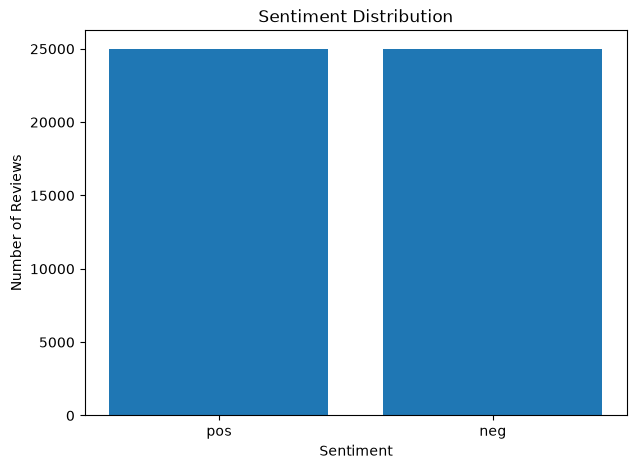

In [30]:
# Visualize sentiment distribution

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.savefig("images/sentiment_distribution.png", bbox_inches="tight")
plt.show()

In [8]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sravy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sravy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sravy\AppData\Roaming\nltk_data...


NLTK resources downloaded successfully!


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [9]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # Tokenisation
    tokens = text.split()
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Join tokens back into text
    return ' '.join(tokens)

print("Preprocessing function created successfully!")

Preprocessing function created successfully!


In [10]:
# Test preprocessing on one review

original_review = df.loc[0, 'review']
cleaned_review = preprocess_text(original_review)

print("ORIGINAL REVIEW:")
print(original_review[:500])

print("\nCLEANED REVIEW:")
print(cleaned_review[:500])

ORIGINAL REVIEW:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s

CLEANED REVIEW:
bromwell high cartoon comedy ran time programs school life teachers years teaching profession lead believe bromwell highs satire much closer reality teachers scramble survive financially insightful students see right pathetic teachers pomp pettiness whole situation remind schools knew students saw episode student repeatedly tried burn school immediately recalled high classic line inspector im sack one teachers student welcome bromwell high expect many adults ag

In [11]:
# Apply preprocessing to all reviews

df['cleaned_review'] = df['review'].apply(preprocess_text)

print("Text preprocessing completed!")
display(df[['review', 'cleaned_review', 'sentiment']].head())

Text preprocessing completed!


,review,cleaned_review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,bromwell high cartoon comedy ran time programs...,pos
1,Homelessness (or Houselessness as George Carli...,homelessness houselessness george carlin state...,pos
2,Brilliant over-acting by Lesley Ann Warren. Be...,brilliant overacting lesley ann warren best dr...,pos
3,This is easily the most underrated film inn th...,easily underrated film inn brooks cannon sure ...,pos
4,This is not the typical Mel Brooks film. It wa...,typical mel brooks film much less slapstick mo...,pos


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is a technique used to convert text data into numerical features that machine learning models can understand.

It gives higher importance to words that are frequent in a particular document but less common across the entire collection of documents. Common words that appear in many documents receive lower importance.

In this project, TF-IDF is used to convert the cleaned movie reviews into numerical feature vectors for sentiment classification.

We will use `TfidfVectorizer` from scikit-learn to perform this feature extraction.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

print("TF-IDF Vectorizer created successfully!")

TF-IDF Vectorizer created successfully!


In [13]:
from sklearn.model_selection import train_test_split

X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [14]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature extraction completed!")
print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

TF-IDF feature extraction completed!
Training feature shape: (40000, 10000)
Testing feature shape: (10000, 10000)


In [15]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [16]:
# Predict sentiment for test reviews
nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes predictions completed!")
print("First 10 predictions:")
print(nb_predictions[:10])

Naive Bayes predictions completed!
First 10 predictions:
['neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg' 'neg']


In [17]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", nb_accuracy)

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.8675

Naive Bayes Classification Report:
              precision    recall  f1-score   support

         neg       0.88      0.85      0.87      5000
         pos       0.86      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



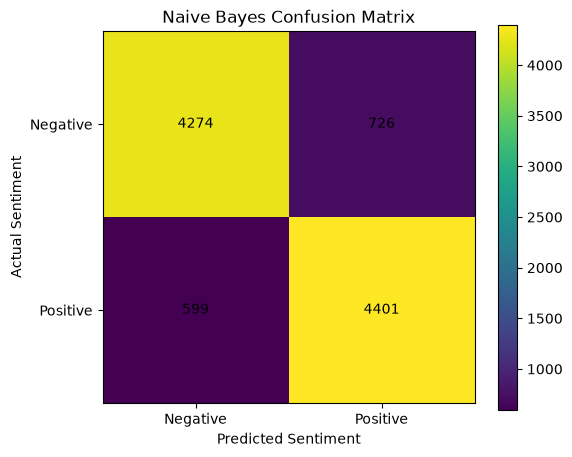

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
nb_cm = confusion_matrix(y_test, nb_predictions, labels=['neg', 'pos'])

plt.figure(figsize=(6, 5))
plt.imshow(nb_cm)
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

# Display numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, nb_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.savefig("images/naive_bayes_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [20]:
# Predict sentiment for test reviews
lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression predictions completed!")
print("First 10 predictions:")
print(lr_predictions[:10])

Logistic Regression predictions completed!
First 10 predictions:
['neg' 'neg' 'pos' 'neg' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg']


In [21]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.8957

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         neg       0.90      0.89      0.89      5000
         pos       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



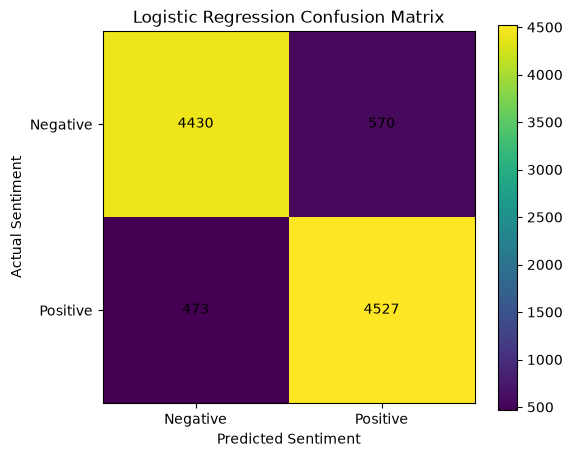

In [37]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
lr_cm = confusion_matrix(y_test, lr_predictions, labels=['neg', 'pos'])

plt.figure(figsize=(6, 5))
plt.imshow(lr_cm)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.xticks([0, 1], ['Negative', 'Positive'])
plt.yticks([0, 1], ['Negative', 'Positive'])

# Display numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, lr_cm[i, j], ha='center', va='center')

plt.colorbar()
plt.savefig("images/logistic_regression_confusion_matrix.png", bbox_inches="tight")
plt.show()

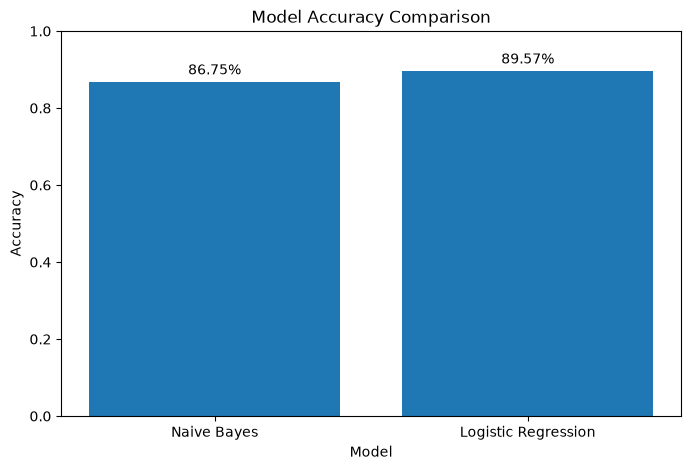

In [34]:
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [nb_accuracy, lr_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, accuracy in enumerate(accuracies):
    plt.text(i, accuracy + 0.02, f"{accuracy:.2%}", ha='center')
plt.savefig("images/model_comparison.png", bbox_inches="tight")

plt.show()

In [24]:
!pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("WordCloud imported successfully!")

WordCloud imported successfully!


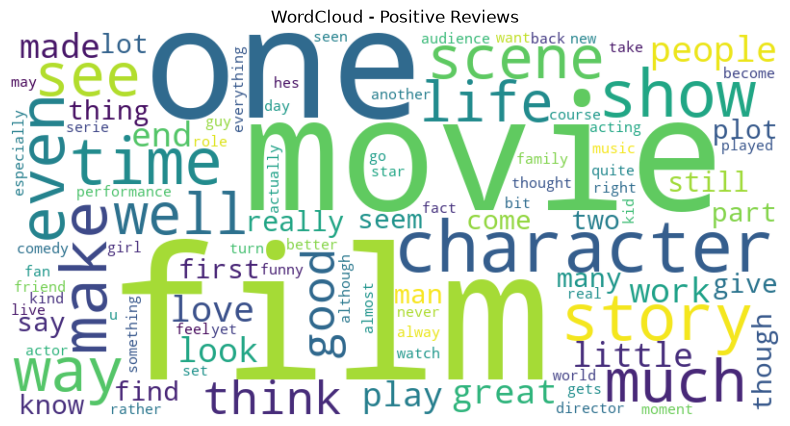

In [32]:
# Combine all positive reviews
positive_text = ' '.join(
    df[df['sentiment'] == 'pos']['cleaned_review']
)

# Create WordCloud
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(positive_text)

# Display WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Positive Reviews")
plt.savefig("images/positive_wordcloud.png", bbox_inches="tight")
plt.show()

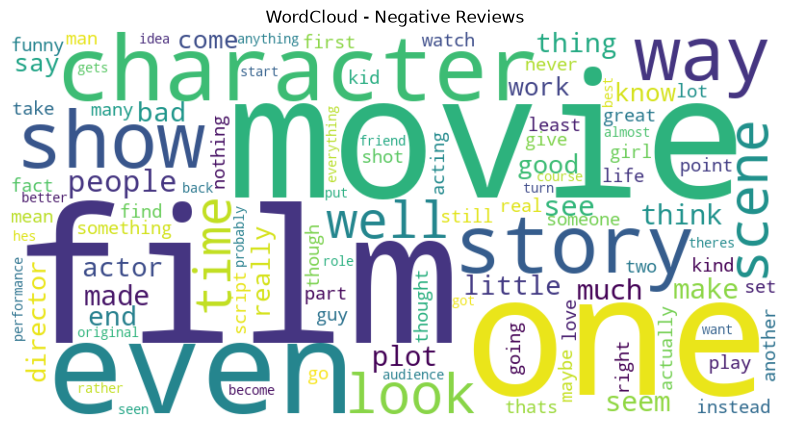

In [35]:
# Combine all negative reviews
negative_text = ' '.join(
    df[df['sentiment'] == 'neg']['cleaned_review']
)

# Create WordCloud
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(negative_text)

# Display WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Negative Reviews")
plt.savefig("images/negative_wordcloud.png", bbox_inches="tight")
plt.show()

In [28]:
# Create a DataFrame for error analysis
error_analysis = pd.DataFrame({
    'review': X_test.values,
    'actual_sentiment': y_test.values,
    'predicted_sentiment': lr_predictions
})

# Select misclassified reviews
misclassified = error_analysis[
    error_analysis['actual_sentiment'] != error_analysis['predicted_sentiment']
]

print("Number of misclassified reviews:", len(misclassified))

print("\nFive Misclassified Reviews:")
display(misclassified.head(5))

Number of misclassified reviews: 1043

Five Misclassified Reviews:


,review,actual_sentiment,predicted_sentiment
8,welli going wait till came video see wish actu...,neg,pos
10,grinch stole christmas wonderful little christ...,neg,pos
14,saw film came let see nowthis guy earlier skie...,neg,pos
27,may differ many people board enjoy watching mi...,pos,neg
39,first nonzombie subgenre review ive done movie...,neg,pos


In [29]:
for index, row in misclassified.head(5).iterrows():
    print("=" * 80)
    print("ACTUAL SENTIMENT   :", row['actual_sentiment'])
    print("PREDICTED SENTIMENT:", row['predicted_sentiment'])
    print("REVIEW:")
    print(row['review'])
    print()

ACTUAL SENTIMENT   : neg
PREDICTED SENTIMENT: pos
REVIEW:
welli going wait till came video see wish actually caught scary movie cable day made yearn got airplane crack mean like airplane leslie nielsen vehicles youll probably heaven used usually wayans comedy dissapointed alot eye candy one keep young hormone raged teenage boys happy probably box office hit first week came enjoyed scary movie ten times fodder part one times much odd better part always liked halloween better original wellmaybe funniest part movie way aliens say goodbye wasnt worth dollars spent catch matinee fiance save cash catch part cable till released video tape rent dont buy

ACTUAL SENTIMENT   : neg
PREDICTED SENTIMENT: pos
REVIEW:
grinch stole christmas wonderful little christmas cartoon anyone could easily enjoy never see reason remake mention remake made humans cartoon perfect enough whats purpose film also seemed little odd jim carrey grinch mean hes great comedic actor grinch didnt make sense performance litt

## Error Analysis

Five misclassified reviews were examined to understand why the Logistic Regression model made incorrect predictions.

The main reasons for misclassification were:

1. **Mixed sentiment:** Some reviews contain both positive and negative opinions. For example, a reviewer may praise an actor or some parts of a movie while strongly criticizing the movie overall.

2. **Positive words in negative reviews:** Some negative reviews contain words such as "great", "wonderful", "enjoyed", "funny", and "good". Since TF-IDF mainly represents word importance, the model may give too much importance to these positive words.

3. **Sarcasm and irony:** Expressions such as "wonderful" or "great" may sometimes be used sarcastically. A TF-IDF-based model has difficulty understanding the intended meaning.

4. **Long reviews:** Some reviews contain many different opinions and details. This can make it difficult for the model to determine the overall sentiment.

5. **Lack of contextual understanding:** TF-IDF represents text using word-based statistical features but does not fully understand the context, relationships between words, or the overall meaning of a sentence.

Overall, the error analysis shows that traditional TF-IDF-based models can achieve good performance but may struggle with sarcasm, mixed opinions, and context-dependent sentiment.


## Model Comparison

Two machine learning classifiers were trained and evaluated for sentiment classification.

| Model               | Accuracy | F1-Score |
| ------------------- | -------: | -------: |
| Naive Bayes         |   86.75% |     0.87 |
| Logistic Regression |   89.57% |     0.90 |

Logistic Regression achieved the highest accuracy and F1-score. Therefore, Logistic Regression is selected as the best-performing model for this project.


## Conclusion

This project developed a machine learning-based sentiment analysis system using IMDb movie reviews.

The reviews were preprocessed by converting text to lowercase, removing HTML tags, punctuation and numbers, tokenising the text, and removing stopwords. TF-IDF was then used to convert the cleaned text into numerical features.

Two machine learning models were trained: Multinomial Naive Bayes and Logistic Regression. Naive Bayes achieved an accuracy of 86.75%, while Logistic Regression achieved a higher accuracy of 89.57%.

Therefore, Logistic Regression was selected as the best-performing model.

### Real-World Applications

Sentiment analysis can be used for:

* Customer feedback analysis
* Product and movie review analysis
* Social media opinion monitoring
* Brand reputation monitoring
* Customer satisfaction analysis

### Dataset Limitation

The IMDb dataset used in this project contains only positive and negative sentiment labels. It does not contain a neutral class. Therefore, this project performs binary sentiment classification rather than three-class classification.
